# Major Project: Seasonal Agriculture Performance Analysis

**Dataset:** Seasonal Agriculture Performance Dataset  
**Objective:** Analyze agricultural performance across seasons, identify seasonal patterns, relationships, group differences, unusual observations, and provide evidence-based recommendations.

This notebook follows the project brief: data understanding → cleaning/preparation → exploratory analysis → seasonal comparisons → relationships/statistics → unusual patterns → conclusions and recommendations.

In [33]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_PATH = 'seasonal_agriculture_performance_dataset (3).csv'
df = pd.read_csv(DATA_PATH)

print('Rows:', df.shape[0], '| Columns:', df.shape[1])



Rows: 4000 | Columns: 28


In [34]:
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 1. Dataset Understanding
The project brief describes data covering seasons, geography, farming practices, environmental conditions, production, resource use and economic performance. The dataset contains 4,000 farm records and 28 columns.

In [36]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_%': (df.isna().mean()*100).round(2),
    'unique_values': df.nunique()
}).sort_values('missing', ascending=False)
display(summary)


,dtype,missing,missing_%,unique_values
Rainfall_mm,float64,48,1.20,3256
Soil_Moisture_pct,float64,40,1.00,343
Yield_Tonnes_Ha,float64,32,0.80,738
Farm_ID,object,0,0.00,4000
Crop,object,0,0.00,8
District,object,0,0.00,10
Farm_Area_Hectares,float64,0,0.00,1370
Season,object,0,0.00,3
Avg_Temperature_C,float64,0,0.00,204
Humidity_pct,float64,0,0.00,573


In [37]:
print('Duplicate rows:', df.duplicated().sum())
for c in df.select_dtypes('object').columns:
    print(f'\n{c}:', df[c].nunique(), 'unique')
    display(df[c].value_counts().head(15))

Duplicate rows: 0

Farm_ID: 4000 unique


,count
Farm_ID,
SF13984,1
SF13983,1
SF13982,1
SF13981,1
SF13980,1
SF13979,1
SF13978,1
SF13977,1
SF13976,1



State: 8 unique


,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



District: 10 unique


...

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Season: 3 unique


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Irrigation_Method: 4 unique


,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## 2. Data Cleaning and Preparation
Only three columns contain missing values: `Rainfall_mm` (48), `Soil_Moisture_pct` (40), and `Yield_Tonnes_Ha` (32). There are no duplicate rows. For analysis, continuous predictors are median-imputed to preserve sample size; the target yield is kept missing for yield-specific statistical tests rather than inventing outcomes.

In [38]:
df_clean = df.copy()

# Median imputation for explanatory numeric variables
for c in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Keep missing Yield_Tonnes_Ha as NaN for target-specific analysis.
# Recalculate/validate derived business measures where possible.
df_clean['Profit_Margin_pct'] = np.where(
    df_clean['Revenue_INR'] != 0,
    df_clean['Profit_INR'] / df_clean['Revenue_INR'] * 100,
    np.nan
)

print('Missing values after preparation:')
display(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print('Rows:', len(df_clean))


Missing values after preparation:


,0
Yield_Tonnes_Ha,32


Rows: 4000


## 3. Univariate Exploration

Season distribution:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


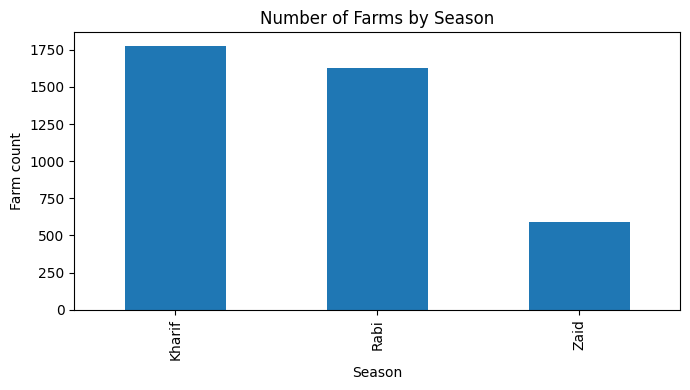

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [39]:
print('Season distribution:')
display(df_clean['Season'].value_counts())

fig, ax = plt.subplots(figsize=(7,4))
df_clean['Season'].value_counts().reindex(['Kharif','Rabi','Zaid']).plot(kind='bar', ax=ax)
ax.set_title('Number of Farms by Season')
ax.set_xlabel('Season'); ax.set_ylabel('Farm count')
plt.tight_layout(); plt.show()

display(df_clean.describe().T)


## 4. Seasonal Performance Comparison
The core project question is how agricultural performance varies by season. We compare yield, production, revenue, cost, profit, water use/efficiency, disease-pest risk, and key environmental conditions.

In [40]:
season_metrics = [
    'Yield_Tonnes_Ha','Production_Tonnes','Market_Price_INR_Tonne',
    'Total_Cost_INR','Revenue_INR','Profit_INR','Water_Used_m3',
    'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct',
    'Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct'
]
season_summary = df_clean.groupby('Season')[season_metrics].agg(['mean','median','std']).round(2)
display(season_summary)


Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.64   1.95 14.42             46.31  13.24 135.70   
Rabi              5.08   1.66 12.83             41.49  11.08 121.90   
Zaid              4.67   1.45 11.32             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3                    \
              std          mean   median      std   
Season                                              
Kharif 611,549.78      6,102.20 4,469.00 5,670.58   
Rabi   489,901.25      5,846.99 4,292.00 5,397.65   
Zaid   436,356.75      6,419.89 4,805.00 5,734.62   

       Water_Efficiency_t_per_1000m3             Disease_Pest_Risk_pct         \
                                mean median  std                  mean median   
Season                                                                          
Kharif                          5.89   3.28 9.83                 54.47  54.50   
Rabi                            5.19   2.74 8.26                 40.48  40.60   
Zaid                            4.41   2.30 6.93                 38.22  37.90   

             Rainfall_mm               Avg_Temperature_C              \
         std        mean median    std              mean median  std   
Season                                                                 
Kharif 10.09      849.20 853.10 183.69             28.45  28.50 2.51   
Rabi   10.10      437.62 432.20 175.35             23.49  23.50 2.46   
Zaid    9.87      304.65 288.20 157.24             31.04  31.00 2.55   

       Humidity_pct             Soil_Moisture_pct              
               mean median  std              mean median  std  
Season                                                         
Kharif        71.81  71.90 8.86             31.15  31.10 5.04  
Rabi          57.89  58.10 9.00             24.07  24.00 4.94  
Zaid          52.01  52.35 9.05             19.28  19.10 4.94

In [41]:
# Mean-only table for easier interpretation
display(df_clean.groupby('Season')[season_metrics].mean().round(2))

,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,,,,,,,,,,
Kharif,5.64,46.31,"44,850.91","531,804.41","710,719.06","178,914.65","6,102.20",5.89,54.47,849.20,28.45,71.81,31.15
Rabi,5.08,41.49,"44,747.97","513,836.58","601,526.05","87,689.47","5,846.99",5.19,40.48,437.62,23.49,57.89,24.07
Zaid,4.67,38.89,"44,212.03","543,976.73","519,171.90","-24,804.82","6,419.89",4.41,38.22,304.65,31.04,52.01,19.28


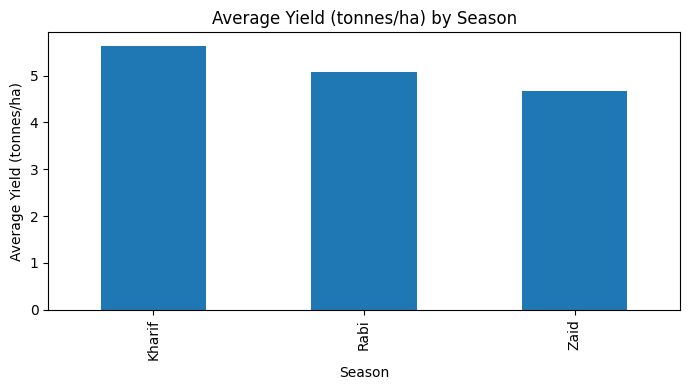

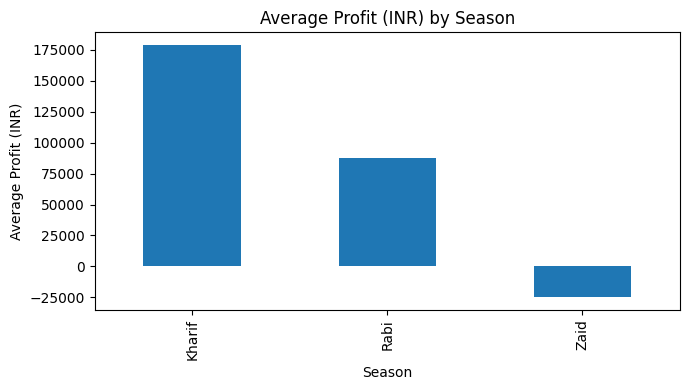

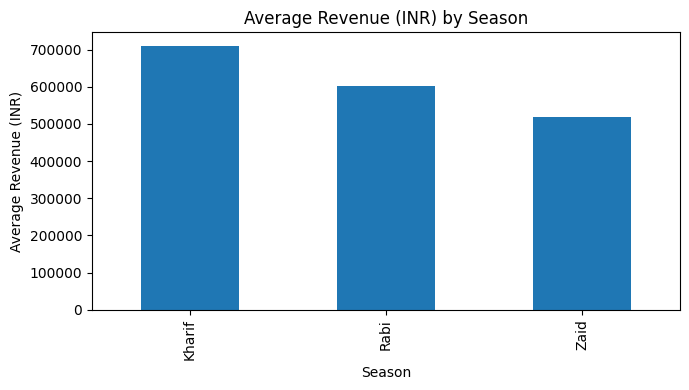

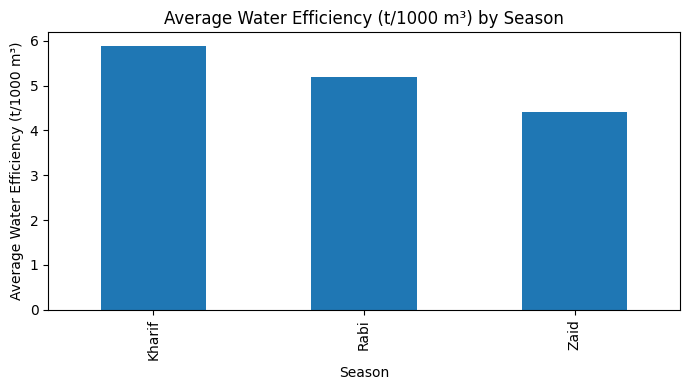

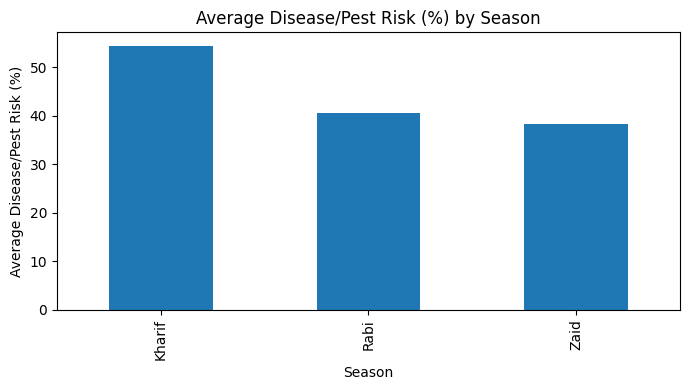

In [42]:
plot_metrics = [
    ('Yield_Tonnes_Ha','Average Yield (tonnes/ha)'),
    ('Profit_INR','Average Profit (INR)'),
    ('Revenue_INR','Average Revenue (INR)'),
    ('Water_Efficiency_t_per_1000m3','Average Water Efficiency (t/1000 m³)'),
    ('Disease_Pest_Risk_pct','Average Disease/Pest Risk (%)')
]
for col, title in plot_metrics:
    fig, ax = plt.subplots(figsize=(7,4))
    df_clean.groupby('Season')[col].mean().reindex(['Kharif','Rabi','Zaid']).plot(kind='bar', ax=ax)
    ax.set_title(title + ' by Season')
    ax.set_xlabel('Season'); ax.set_ylabel(title)
    plt.tight_layout(); plt.show()


### Key seasonal observations
- **Kharif** has the highest average yield, revenue and profit among the three seasons.
- **Rabi** is intermediate on most economic measures.
- **Zaid** has the lowest average yield and profit and the highest average loss rate.
- Disease/pest risk is substantially higher in Kharif than in Rabi/Zaid.
- Yield means are heavily influenced by the high-yield Sugarcane records, so medians and crop-level comparisons should also be considered.

## 5. Distribution and Outlier Analysis

In [43]:
outlier_cols = ['Yield_Tonnes_Ha','Production_Tonnes','Revenue_INR','Profit_INR',
                 'Water_Used_m3','Water_Efficiency_t_per_1000m3']
outlier_report=[]
for c in outlier_cols:
    s=df_clean[c].dropna()
    q1,q3=s.quantile([.25,.75]); iqr=q3-q1
    low,high=q1-1.5*iqr,q3+1.5*iqr
    n=((s<low)|(s>high)).sum()
    outlier_report.append([c,q1,q3,low,high,n,round(n/len(s)*100,2)])
outlier_report=pd.DataFrame(outlier_report, columns=['Variable','Q1','Q3','Lower_Bound','Upper_Bound','Outlier_Count','Outlier_%'])
display(outlier_report)

,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Yield_Tonnes_Ha,1.05,2.84,-1.63,5.52,302,7.61
1,Production_Tonnes,5.02,24.36,-23.98,53.36,333,8.33
2,Revenue_INR,"207,517.25","836,874.75","-736,519.00","1,780,911.00",240,6.00
3,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404,10.10
4,Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276,6.90
5,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322,8.05


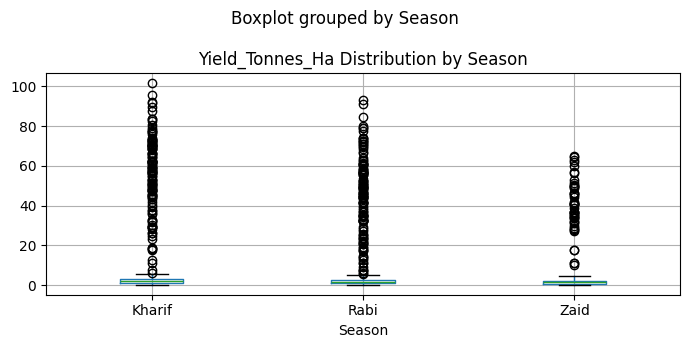

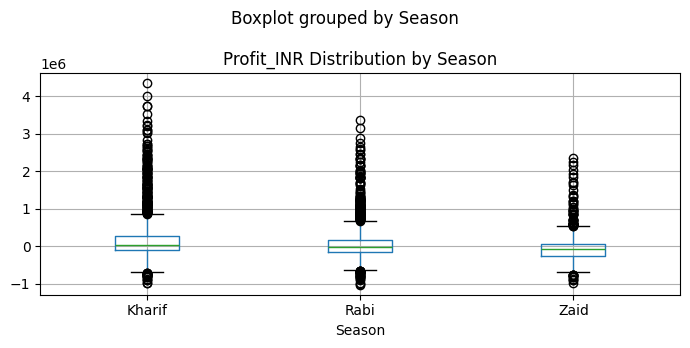

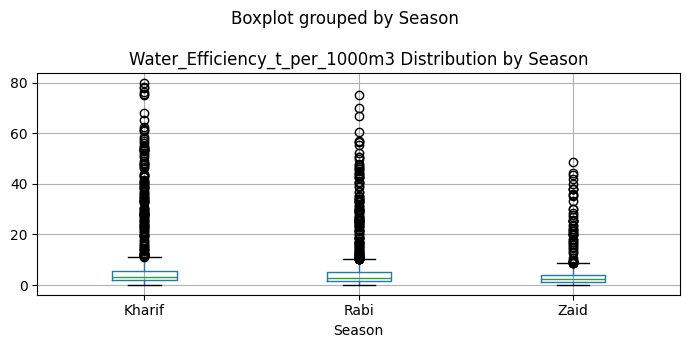

In [44]:

for c in ['Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3']:
    fig, ax=plt.subplots(figsize=(7,3.5))
    df_clean.boxplot(column=c, by='Season', ax=ax)
    ax.set_title(f'{c} Distribution by Season')
    plt.tight_layout(); plt.show()


**Interpretation:** Many statistical outliers are legitimate rather than data errors. For example, Sugarcane has dramatically higher yield than the other crops, which naturally creates extreme values. Therefore, outliers should not be deleted automatically; use medians, stratified analysis and suitable plots/log scales.

## 6. Crop and Season Analysis

In [45]:
crop_season = df_clean.groupby(['Season','Crop']).agg(
    farms=('Farm_ID','size'),
    avg_yield=('Yield_Tonnes_Ha','mean'),
    median_yield=('Yield_Tonnes_Ha','median'),
    avg_profit=('Profit_INR','mean'),
    loss_rate=('Profit_INR', lambda x: (x<0).mean()*100)
).round(2)
display(crop_season)

farms  avg_yield  median_yield   avg_profit  loss_rate
Season Crop                                                             
Kharif Chilli       185       1.73          1.78   954,380.42      14.59
       Cotton       215       1.37          1.44   216,999.55      27.91
       Groundnut    193       1.48          1.52   108,265.44      33.16
       Maize        234       2.97          3.12   -39,332.67      53.42
       Pulses       221       1.04          1.09    43,338.90      37.10
       Rice         314       2.71          2.88   -64,903.40      58.60
       Sugarcane    125      53.46         56.65 1,000,790.81       8.00
       Wheat        292       2.26          2.36  -105,871.87      68.15
Rabi   Chilli       163       1.46          1.56   638,572.50      21.47
       Cotton       201       1.19          1.20   107,343.59      33.83
       Groundnut    177       1.22          1.29    10,416.54      43.50
       Maize        233       2.61          2.82   -89,133.40      66.52
       Pulses       213       0.87          0.90   -14,309.14      53.99
       Rice         274       2.33          2.38   -98,427.87      67.52
       Sugarcane    129      43.94         45.46   731,612.86      14.73
       Wheat        237       2.06          2.22  -119,954.57      75.11
Zaid   Chilli        64       1.18          1.22   448,659.09      18.75
       Cotton        92       0.95          0.97   -53,925.34      52.17
       Groundnut     54       1.04          1.10   -68,872.50      59.26
       Maize         84       2.30          2.27  -194,049.17      84.52
       Pulses        62       0.65          0.66  -139,227.81      75.81
       Rice         102       1.90          1.94  -227,239.34      87.25
       Sugarcane     51      38.42         38.78   583,635.80      11.76
       Wheat         85       1.75          1.84  -193,208.95      91.76

In [46]:
pivot_yield = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')
display(pivot_yield.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


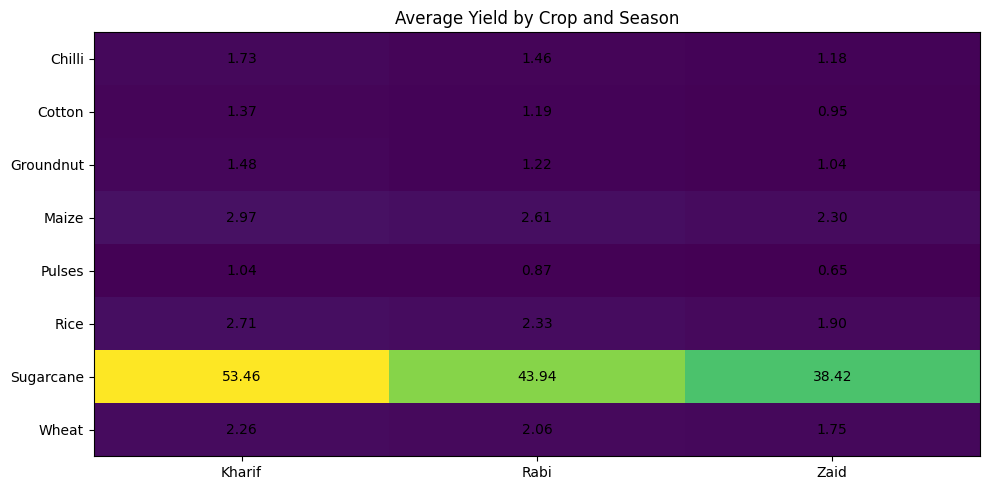

In [47]:
fig, ax=plt.subplots(figsize=(10,5))
im=ax.imshow(pivot_yield.values, aspect='auto'); ax.set_xticks(range(len(pivot_yield.columns))); ax.set_xticklabels(pivot_yield.columns); ax.set_yticks(range(len(pivot_yield.index))); ax.set_yticklabels(pivot_yield.index); [ax.text(j,i,f'{pivot_yield.iloc[i,j]:.2f}',ha='center',va='center') for i in range(len(pivot_yield.index)) for j in range(len(pivot_yield.columns))]
ax.set_title('Average Yield by Crop and Season')
plt.tight_layout(); plt.show()


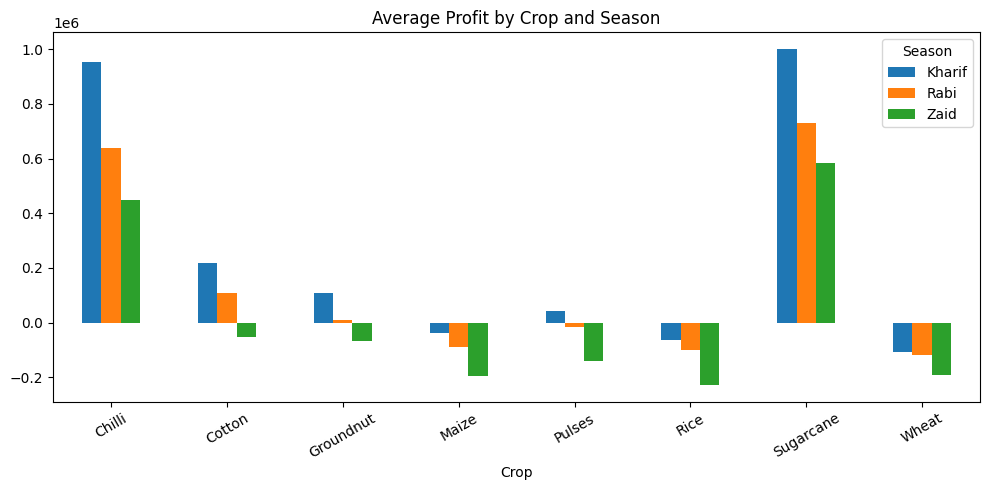

In [48]:
fig, ax=plt.subplots(figsize=(10,5))
df_clean.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=['Kharif','Rabi','Zaid']).plot(kind='bar', ax=ax)
ax.set_title('Average Profit by Crop and Season')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 7. Region and Irrigation Comparisons

In [49]:
state_season_profit = df_clean.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean')
display(state_season_profit.round(0))

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,"169,316.00","26,316.00","-84,085.00"
Gujarat,"217,051.00","82,846.00","-106,930.00"
Karnataka,"201,226.00","70,953.00","23,311.00"
Madhya Pradesh,"134,242.00","61,576.00",210.00
Maharashtra,"168,801.00","159,582.00","-40,598.00"
Punjab,"133,779.00","169,295.00","62,110.00"
Tamil Nadu,"211,304.00","70,457.00","-15,175.00"
Telangana,"199,668.00","62,825.00","-34,621.00"


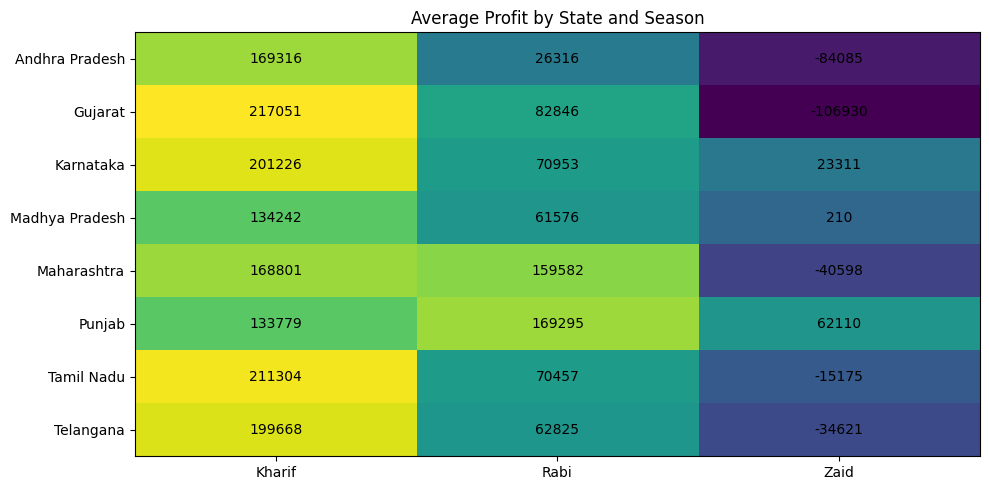

In [50]:
fig, ax=plt.subplots(figsize=(10,5))
im=ax.imshow(state_season_profit.values, aspect='auto'); ax.set_xticks(range(len(state_season_profit.columns))); ax.set_xticklabels(state_season_profit.columns); ax.set_yticks(range(len(state_season_profit.index))); ax.set_yticklabels(state_season_profit.index); [ax.text(j,i,f'{state_season_profit.iloc[i,j]:.0f}',ha='center',va='center') for i in range(len(state_season_profit.index)) for j in range(len(state_season_profit.columns))]
ax.set_title('Average Profit by State and Season')
plt.tight_layout(); plt.show()

In [51]:
irrigation_summary = df_clean.groupby('Irrigation_Method').agg(
    farms=('Farm_ID','size'),
    avg_yield=('Yield_Tonnes_Ha','mean'),
    median_yield=('Yield_Tonnes_Ha','median'),
    avg_profit=('Profit_INR','mean'),
    avg_water=('Water_Used_m3','mean'),
    avg_water_eff=('Water_Efficiency_t_per_1000m3','mean'),
    loss_rate=('Profit_INR', lambda x:(x<0).mean()*100)
).round(2)
display(irrigation_summary)

,farms,avg_yield,median_yield,avg_profit,avg_water,avg_water_eff,loss_rate
Irrigation_Method,,,,,,,
Drip,915,6.62,1.96,"219,626.00","5,918.75",6.27,40.22
Flood,1310,4.90,1.63,"73,354.02","8,026.47",3.44,52.82
Rainfed,1041,4.61,1.72,"79,050.37","3,549.55",7.56,53.12
Sprinkler,734,5.19,1.80,"91,121.08","6,208.26",4.67,48.09


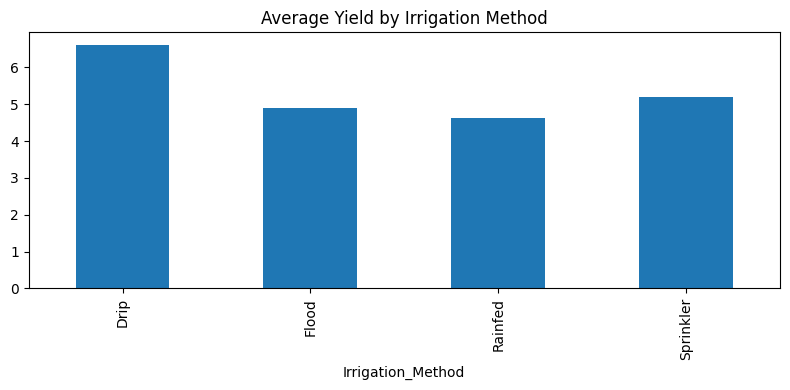

In [52]:
fig, ax=plt.subplots(figsize=(8,4))
df_clean.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average Yield by Irrigation Method')
plt.tight_layout(); plt.show()


## 8. Environmental Conditions and Resource Use

In [53]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
            'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha',
            'Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
            'Seed_Quality_Score','Water_Used_m3','Disease_Pest_Risk_pct']
spearman = df_clean[env_cols+['Yield_Tonnes_Ha']].corr(method='spearman')['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
display(spearman.to_frame('Spearman correlation with yield'))

,Spearman correlation with yield
Water_Used_m3,0.27
Rainfall_mm,0.13
Soil_Moisture_pct,0.10
Nitrogen_kg_ha,0.08
Humidity_pct,0.08
Disease_Pest_Risk_pct,0.07
Sunlight_Hours_Day,-0.05
Phosphorus_kg_ha,0.05
Soil_pH,-0.03
Potassium_kg_ha,0.03


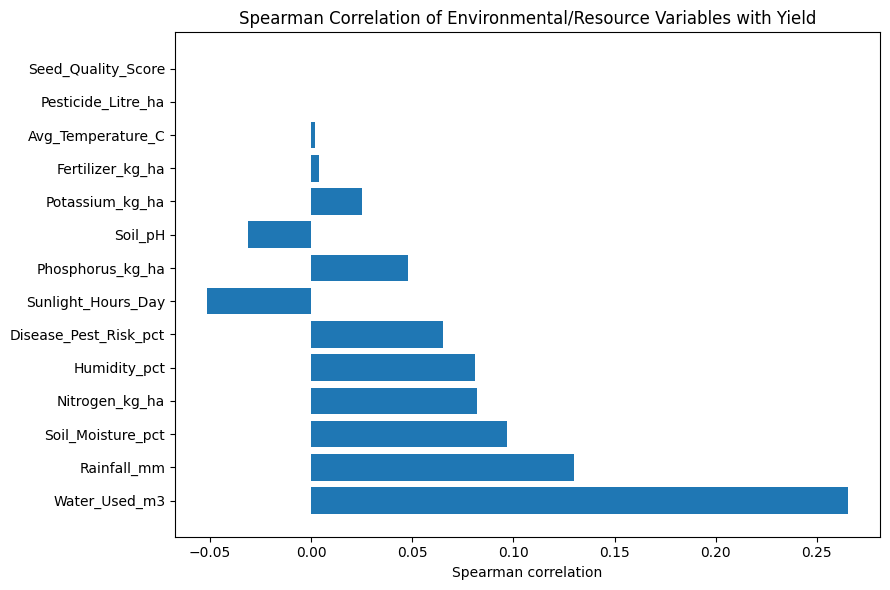

In [54]:
fig, ax=plt.subplots(figsize=(9,6))
ax.barh(spearman.index, spearman.values)
ax.set_title('Spearman Correlation of Environmental/Resource Variables with Yield')
ax.set_xlabel('Spearman correlation'); ax.set_ylabel('')
plt.tight_layout(); plt.show()


**Important caution:** Correlation does not prove causation. Some relationships can also reflect crop mix, farm size, geography, or the construction of the dataset. In particular, production is mechanically related to yield and farm area, so it should not be interpreted as an independent causal driver.

## 9. Economic Performance

In [55]:
economic = df_clean.groupby('Season').agg(
    avg_cost=('Total_Cost_INR','mean'),
    avg_revenue=('Revenue_INR','mean'),
    avg_profit=('Profit_INR','mean'),
    median_profit=('Profit_INR','median'),
    loss_rate=('Profit_INR', lambda x:(x<0).mean()*100),
    avg_margin=('Profit_Margin_pct','mean')
).round(2)
display(economic)

,avg_cost,avg_revenue,avg_profit,median_profit,loss_rate,avg_margin
Season,,,,,,
Kharif,"531,804.41","710,719.06","178,914.65","38,808.00",42.21,-38.64
Rabi,"513,836.58","601,526.05","87,689.47","-3,187.00",51.14,-44.27
Zaid,"543,976.73","519,171.90","-24,804.82","-62,144.00",64.48,-69.35


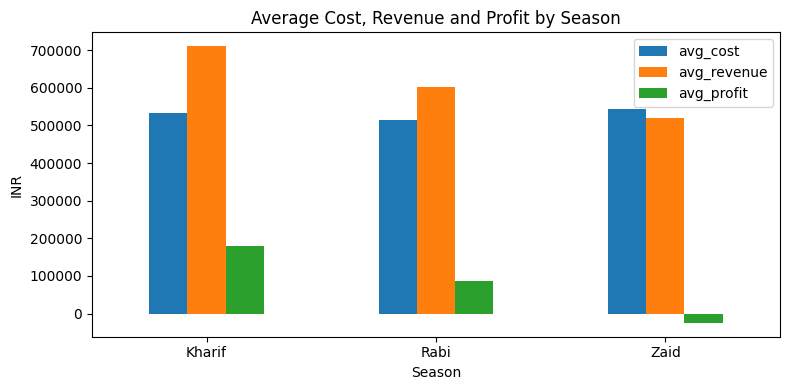

In [56]:
fig, ax=plt.subplots(figsize=(8,4))
econ_plot = economic[['avg_cost','avg_revenue','avg_profit']]
econ_plot.plot(kind='bar', ax=ax)
ax.set_title('Average Cost, Revenue and Profit by Season')
ax.set_ylabel('INR')
ax.set_xlabel('Season')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


## 10. Statistical Tests for Seasonal Differences
Because yield and financial variables are strongly skewed and contain outliers, use both parametric and non-parametric evidence. The Kruskal–Wallis test is particularly useful for comparing distributions across the three seasons.

In [57]:
# Complete-case yield values
yield_groups = [df_clean.loc[df_clean['Season']==s,'Yield_Tonnes_Ha'].dropna()
                for s in ['Kharif','Rabi','Zaid']]

anova = stats.f_oneway(*yield_groups)
kruskal = stats.kruskal(*yield_groups)

print('One-way ANOVA for Yield:')
print('F =', round(anova.statistic,3), '| p =', anova.pvalue)
print('\nKruskal-Wallis test for Yield:')
print('H =', round(kruskal.statistic,3), '| p =', kruskal.pvalue)

# Seasonal tests for selected outcomes
tests=[]
for c in ['Production_Tonnes','Revenue_INR','Total_Cost_INR','Profit_INR',
          'Water_Used_m3','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']:
    gs=[df_clean.loc[df_clean['Season']==s,c].dropna() for s in ['Kharif','Rabi','Zaid']]
    h,p=stats.kruskal(*gs)
    tests.append([c,h,p])
tests_df=pd.DataFrame(tests,columns=['Variable','Kruskal_H','p_value'])
tests_df['Significant_at_0.05']=tests_df['p_value']<0.05
display(tests_df)


One-way ANOVA for Yield:
F = 1.458 | p = 0.23283549440109827

Kruskal-Wallis test for Yield:
H = 68.604 | p = 1.2669705784969668e-15


,Variable,Kruskal_H,p_value,Significant_at_0.05
0,Production_Tonnes,26.10,0.00,True
1,Revenue_INR,40.85,0.00,True
2,Total_Cost_INR,5.39,0.07,False
3,Profit_INR,101.93,0.00,True
4,Water_Used_m3,5.97,0.05,False
5,Water_Efficiency_t_per_1000m3,56.81,0.00,True
6,Disease_Pest_Risk_pct,"1,430.91",0.00,True


### Statistical interpretation
- Yield shows a **highly significant distributional difference** across seasons under Kruskal–Wallis, while one-way ANOVA on the raw mean is not significant. This contrast is consistent with the strong skew/outliers in yield, especially from Sugarcane. The safer conclusion is that **season affects the distribution of yield**, not simply that one season has a statistically different mean.
- Revenue, profit, water efficiency and disease/pest risk also show significant seasonal distributional differences in the dataset.
- Statistical significance indicates an observed difference in this sample; it does not by itself establish causality.

## 11. Data Consistency Checks

In [58]:
# Check arithmetic relationships
checks = {
    'Profit = Revenue - Cost': np.nanmax(np.abs(df_clean['Profit_INR'] - (df_clean['Revenue_INR']-df_clean['Total_Cost_INR']))),
    'Revenue ≈ Production × Market Price': np.nanmax(np.abs(df_clean['Revenue_INR'] - df_clean['Production_Tonnes']*df_clean['Market_Price_INR_Tonne'])),
    'Production ≈ Yield × Area': np.nanmax(np.abs(df_clean['Production_Tonnes'] - df_clean['Yield_Tonnes_Ha']*df_clean['Farm_Area_Hectares']))
}
display(pd.Series(checks, name='maximum absolute difference'))




,maximum absolute difference
Profit = Revenue - Cost,0.00
Revenue ≈ Production × Market Price,0.50
Production ≈ Yield × Area,0.01


In [59]:
print('Rows with negative profit:', (df_clean['Profit_INR']<0).sum())
print('Rows with zero/negative revenue:', (df_clean['Revenue_INR']<=0).sum())

Rows with negative profit: 1966
Rows with zero/negative revenue: 0


## 12. Key Findings

1. **Kharif is the strongest season economically:** it has the highest average yield, revenue and profit in the observed data.
2. **Zaid is the weakest season:** it has the lowest average yield and average profit, and the highest proportion of loss-making farms.
3. **Seasonal risk differs:** average disease/pest risk is highest in Kharif and lowest in Zaid.
4. **Crop choice is a major driver of observed performance:** Sugarcane has much higher yield and profit than the other crops, while several crops show much lower profitability.
5. **Irrigation matters descriptively:** Drip-irrigated farms show the highest average yield and water efficiency in this dataset. This is an association, not proof that irrigation method alone causes the difference.
6. **Water efficiency is strongly associated with yield:** the Spearman relationship is positive and substantial in this dataset.
7. **Yield is highly skewed:** mean-based comparisons can be misleading, so median, crop-stratified and non-parametric analysis are important.
8. **Economic outcomes vary strongly by season:** profit and revenue show statistically significant seasonal distributional differences.
9. **Regional seasonality is not uniform:** some states perform relatively better in Rabi or Zaid than others, suggesting that local conditions/crop mix matter.
10. **Missing data are limited:** only three variables contain missing values, and there are no duplicate records.

## 13. Data-Driven Recommendations

### For seasonal planning
- Prioritize **Kharif opportunities** where historical profitability and yield are favorable, while planning stronger disease/pest management.
- Treat **Zaid as a higher financial-risk season** and review crop selection, irrigation needs and expected market prices before planting.
- Use **state- and crop-specific plans** rather than applying one seasonal strategy to every region.

### For resource management
- Investigate **drip irrigation** as a potentially water-efficient practice, while controlling for crop and region before making causal claims.
- Monitor water efficiency alongside yield rather than maximizing water use alone.

### For crop decisions
- Compare crops within the same season and region. The dataset shows substantial crop-level differences, especially the unusually high performance of Sugarcane.
- Evaluate profitability, not yield alone, because high production does not automatically guarantee high profit.

### For risk management
- Increase pest/disease monitoring during Kharif.
- Use scenario analysis for market prices and production costs before making seasonal crop decisions.

### For future analysis
- Add time-series information, weather forecasts, input prices and farm-level historical records.
- A multivariate model could separate the effects of season, crop, state, irrigation and environmental conditions.
- Because this dataset contains strong outliers and likely mixed crop populations, future models should consider log transformations, robust regression or crop-stratified models.

## 14. Final Conclusion

The analysis shows clear and meaningful **seasonal variation in agricultural outcomes**, especially in profitability, revenue, water efficiency and disease/pest risk. Kharif is the strongest overall season in the observed sample, while Zaid presents the greatest profitability risk. However, season alone does not explain agricultural performance: crop type, region, irrigation and resource conditions also differ substantially.

The most defensible planning approach is therefore **season-aware and crop/region-specific**, supported by profitability, water-efficiency and risk indicators rather than yield alone. These findings meet the project objectives by identifying patterns, comparing groups, testing differences, examining relationships and translating the evidence into practical recommendations.